# 4 - Teste v2

O teste da versao 2 agora tambem segue o regime de arquivo unico. Isso facilita comparar arquiteturas sem a variabilidade extra de muitos arquivos, mantendo uma avaliacao honesta no trecho final da mesma serie temporal.


In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error
from torch.utils.data import DataLoader

from pipeline_v2 import (
    GroupedWindowDataset,
    HybridResidualForecaster,
    compute_global_metrics,
    compute_per_feature_metrics,
    inverse_transform_targets,
    load_bundle,
    load_grouped_sequences_from_directory,
    predict_loader,
    set_seed,
)

#configura reproducibilidade e exibicao
set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


## 1. Carga do modelo e do conjunto de teste


In [2]:
PROJECT_ROOT = Path.cwd()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESSED_V2_DIR = ARTIFACTS_DIR / "preprocessed_v2"
BUNDLE_PATH = PREPROCESSED_V2_DIR / "preprocessing_bundle_v2.json"
MODEL_CONFIG_PATH = ARTIFACTS_DIR / "models" / "hybrid_residual_forecaster_v2_config.json"
MODEL_PATH = ARTIFACTS_DIR / "models" / "hybrid_residual_forecaster_v2.pt"

bundle = load_bundle(BUNDLE_PATH)
model_config = json.loads(MODEL_CONFIG_PATH.read_text())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo: {device}")
print(model_config)


Dispositivo: cpu
{'model_name': 'hybrid_residual_forecaster_v2', 'sequence_length': 60, 'input_size': 24, 'target_size': 6, 'raw_target_positions': [0, 1, 2, 3, 4, 5], 'model_dim': 128, 'gru_hidden_size': 128, 'gru_layers': 2, 'well_embedding_dim': 16, 'dropout': 0.2, 'train_batch_size': 256, 'validation_batch_size': 512, 'max_epochs': 50, 'patience': 8, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'best_epoch': 10, 'best_val_mae': 0.007878802716732025, 'best_val_persistence_mae': 0.02088732086122036, 'best_ratio_to_persistence': 0.377205040755605, 'executed_epochs': 18, 'bundle_path': '/Users/tiagoriosdarocha/Desktop/lstm-w3/versao2/artifacts/preprocessed_v2/preprocessing_bundle_v2.json', 'model_path': '/Users/tiagoriosdarocha/Desktop/lstm-w3/versao2/artifacts/models/hybrid_residual_forecaster_v2.pt'}


In [3]:
#reconstroi o modelo salvo e carrega todas as janelas de teste
RAW_TARGET_POSITIONS = model_config["raw_target_positions"]

model = HybridResidualForecaster(
    input_size=model_config["input_size"],
    target_size=model_config["target_size"],
    well_count=max(len(bundle.well_to_id), 1),
    raw_target_positions=RAW_TARGET_POSITIONS,
    model_dim=model_config["model_dim"],
    gru_hidden_size=model_config["gru_hidden_size"],
    gru_layers=model_config["gru_layers"],
    well_embedding_dim=model_config["well_embedding_dim"],
    dropout=model_config["dropout"],
).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

test_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V2_DIR / "test",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)
test_dataset = GroupedWindowDataset(
    groups=test_groups,
    sequence_length=model_config["sequence_length"],
    sampled_windows=None,
    seed=999,
)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

{
    "series_de_teste": len(test_groups),
    "janelas_de_teste": len(test_dataset),
}


{'series_de_teste': 1, 'janelas_de_teste': 3162}

## 2. Inferencia e baseline

O baseline continua sendo a persistencia: prever que o proximo valor sera igual ao ultimo valor observado da janela.


In [4]:
#gera previsoes do modelo e do baseline de persistencia
predictions_df = predict_loader(
    model=model,
    loader=test_loader,
    device=device,
    raw_target_positions=RAW_TARGET_POSITIONS,
    groups=test_groups,
)

feature_names = bundle.target_columns
scaled_true = predictions_df[[f"real__{column}" for column in feature_names]].to_numpy(dtype=np.float32)
scaled_pred = predictions_df[[f"pred__{column}" for column in feature_names]].to_numpy(dtype=np.float32)
scaled_persist = predictions_df[[f"persist__{column}" for column in feature_names]].to_numpy(dtype=np.float32)

original_true = inverse_transform_targets(scaled_true, bundle)
original_pred = inverse_transform_targets(scaled_pred, bundle)
original_persist = inverse_transform_targets(scaled_persist, bundle)

print(predictions_df.shape)
predictions_df.head()


(3162, 22)


,series_id,well_name,step_idx,timestamp,real__P-ANULAR,pred__P-ANULAR,persist__P-ANULAR,real__P-JUS-CKGL,pred__P-JUS-CKGL,persist__P-JUS-CKGL,real__P-MON-CKP,pred__P-MON-CKP,persist__P-MON-CKP,real__P-TPT,pred__P-TPT,persist__P-TPT,real__T-JUS-CKP,pred__T-JUS-CKP,persist__T-JUS-CKP,real__T-TPT,pred__T-TPT,persist__T-TPT
0,test__WELL-00001_20170201010207,WELL-00001,60,2017-02-01 06:07:19,-1.144632,-1.144052,-1.144632,1.728244,1.731644,1.728244,-0.025499,-0.013237,-0.095363,0.483145,0.482380,0.481152,0.347957,0.352507,0.320195,-0.640378,-0.646463,-0.634065
1,test__WELL-00001_20170201010207,WELL-00001,61,2017-02-01 06:07:20,-1.144632,-1.143842,-1.144632,1.728244,1.731528,1.728244,0.044366,0.056567,-0.025499,0.485138,0.484460,0.483145,0.375739,0.381121,0.347957,-0.646458,-0.651925,-0.640378
2,test__WELL-00001_20170201010207,WELL-00001,62,2017-02-01 06:07:21,-1.144632,-1.143782,-1.144632,1.728244,1.731692,1.728244,0.114231,0.129189,0.044366,0.487132,0.486301,0.485138,0.403557,0.409631,0.375739,-0.655577,-0.657334,-0.646458
3,test__WELL-00001_20170201010207,WELL-00001,63,2017-02-01 06:07:22,-1.144632,-1.143747,-1.144632,1.728244,1.731104,1.728244,0.184096,0.202138,0.114231,0.489125,0.488266,0.487132,0.431320,0.436934,0.403557,-0.661657,-0.667665,-0.655577
4,test__WELL-00001_20170201010207,WELL-00001,64,2017-02-01 06:07:23,-1.144632,-1.143789,-1.144632,1.728244,1.731616,1.728244,0.253960,0.267489,0.184096,0.491118,0.490235,0.489125,0.459101,0.465083,0.431320,-0.671010,-0.672749,-0.661657


## 3. Metricas globais e por feature

Primeiro avaliamos em escala padronizada. Depois, convertemos para a escala original para facilitar interpretacao fisica.


In [5]:
global_metrics_scaled_df = pd.DataFrame(
    [
        compute_global_metrics(scaled_true, scaled_pred, "Modelo_v2"),
        compute_global_metrics(scaled_true, scaled_persist, "Persistencia"),
    ]
)

global_metrics_original_df = pd.DataFrame(
    [
        compute_global_metrics(original_true, original_pred, "Modelo_v2"),
        compute_global_metrics(original_true, original_persist, "Persistencia"),
    ]
)

print("Escala padronizada")
display(global_metrics_scaled_df)
print("Escala original")
global_metrics_original_df


Escala padronizada


,modelo,MSE,RMSE,MAE,MedAE,R2_medio,ExplainedVariance_media
0,Modelo_v2,0.000511,0.022600,0.007636,0.001776,0.832907,0.832911
1,Persistencia,0.002656,0.051535,0.020833,0.000000,0.997805,0.997805


Escala original


,modelo,MSE,RMSE,MAE,MedAE,R2_medio,ExplainedVariance_media
0,Modelo_v2,14152045.0,3761.920387,914.718140,2.75,0.832907,0.832911
1,Persistencia,70758848.0,8411.827863,2614.476807,0.00,0.997805,0.997805


In [6]:
per_feature_scaled_df = compute_per_feature_metrics(
    y_true=scaled_true,
    y_pred=scaled_pred,
    y_baseline=scaled_persist,
    feature_names=feature_names,
)
per_feature_original_df = compute_per_feature_metrics(
    y_true=original_true,
    y_pred=original_pred,
    y_baseline=original_persist,
    feature_names=feature_names,
)

print("Escala padronizada")
display(per_feature_scaled_df)
print("Escala original")
per_feature_original_df


Escala padronizada


,feature,model_mae,baseline_mae,mae_melhora_pct,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
0,P-MON-CKP,0.031264,0.090542,65.470380,0.053292,0.119167,55.279411,0.997706,0.988530,0.000416,0.053291
1,T-JUS-CKP,0.008164,0.030299,73.054783,0.014089,0.040798,65.467445,0.999817,0.998468,0.001385,0.014020
2,T-TPT,0.002366,0.002927,19.185325,0.004249,0.008153,47.883036,0.999958,0.999845,0.000255,0.004241
3,P-JUS-CKGL,0.001447,0.000000,NaN,0.001784,0.000000,NaN,0.000000,1.000000,0.001296,0.001226
4,P-TPT,0.001367,0.000948,-44.290019,0.001639,0.001721,4.788834,0.999998,0.999998,0.000728,0.001468
5,P-ANULAR,0.001208,0.000284,-325.603674,0.001411,0.000789,-78.808988,0.999963,0.999988,0.001031,0.000964


Escala original


,feature,model_mae,baseline_mae,mae_melhora_pct,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
0,P-MON-CKP,5405.687988,15655.208984,65.470356,9214.512467,20604.627053,55.279402,0.997706,0.988530,71.887177,9214.232422
1,P-ANULAR,53.799179,12.618596,-326.348373,62.819146,35.079200,-79.078045,0.999963,0.999988,45.941494,42.844189
2,P-TPT,27.543959,19.019608,-44.818754,33.001102,34.545939,4.471832,0.999998,0.999998,14.853257,29.469536
3,P-JUS-CKGL,1.273561,0.000000,NaN,1.568916,0.000000,NaN,0.000000,1.000000,1.144766,1.072850
4,T-JUS-CKP,0.003347,0.012423,73.060195,0.005776,0.016728,65.469146,0.999817,0.998468,0.000565,0.005749
5,T-TPT,0.000078,0.000096,18.772262,0.000139,0.000266,47.829861,0.999958,0.999845,0.000011,0.000138


### Leitura dos resultados observados

No teste, a `versao2` confirmou o ganho visto na validacao:

- `MAE` global na escala padronizada: `0.007636` no modelo contra `0.020833` na persistencia
- `RMSE` global na escala padronizada: `0.022600` no modelo contra `0.051535` na persistencia
- ganho global de `65,01%` em `MAE`
- ganho global de `55,28%` em `RMSE`
- `3.162` janelas avaliadas no conjunto de teste

Na escala original, o resultado manteve a mesma leitura: `MAE` de `914,72` para o modelo contra `2.614,48` na persistencia.

Existe um detalhe academico importante aqui: o `R2 medio` da persistencia ficou maior que o do modelo (`0.9978` contra `0.8329`), mas isso nao contradiz os ganhos em `MAE` e `RMSE`. Isso acontece porque:

- `MAE` e `RMSE` globais foram calculados sobre todos os valores achatados, o que da mais peso as variaveis de maior escala
- `R2_medio` foi calculado como media uniforme por feature, dando o mesmo peso para variaveis muito grandes e para variaveis quase constantes

Entao a leitura correta e: o modelo ficou muito melhor nas variaveis mais dinamicas e relevantes para erro absoluto total, mas ainda perdeu para a persistencia em algumas features muito estaveis.


## 4. Graficos comparativos

Num unico arquivo, a leitura fica ainda mais direta: ou o modelo aproxima melhor a serie do que a persistencia, ou continua distante mesmo com uma arquitetura mais forte.


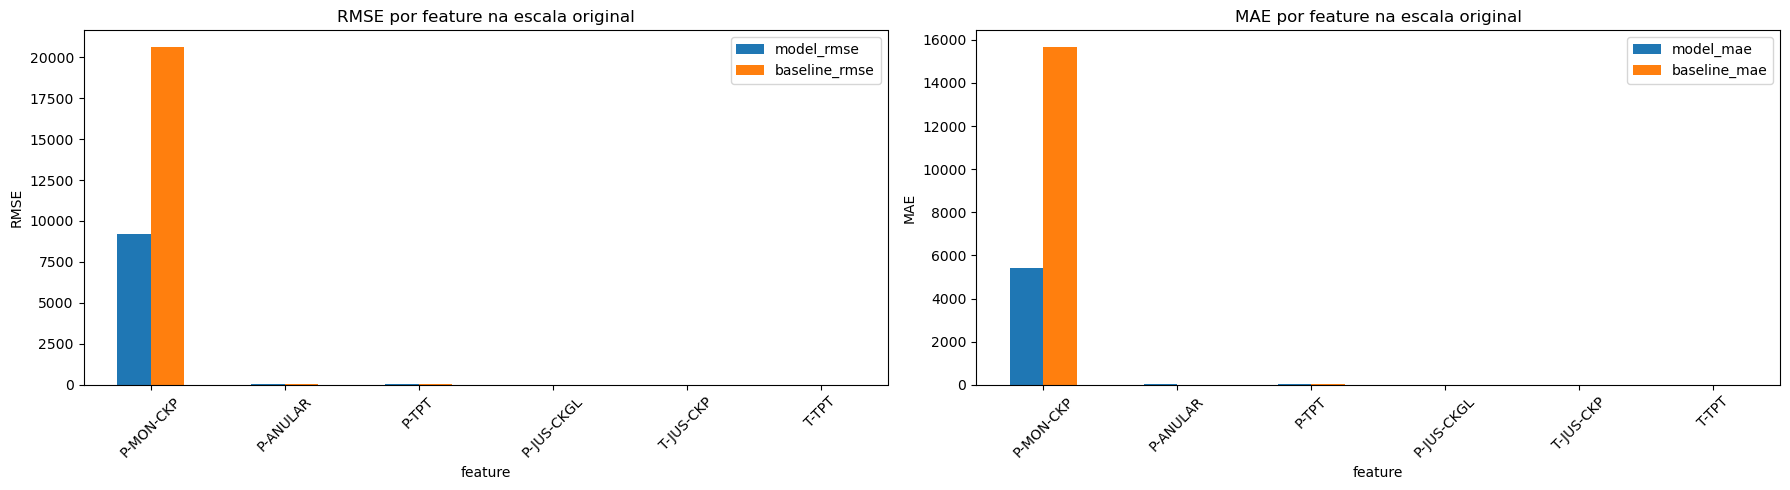

In [7]:
#compara modelo e persistencia nas metricas principais por feature
compare_plot_df = per_feature_original_df.set_index("feature")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
compare_plot_df[["model_rmse", "baseline_rmse"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("RMSE por feature na escala original")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

compare_plot_df[["model_mae", "baseline_mae"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE por feature na escala original")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


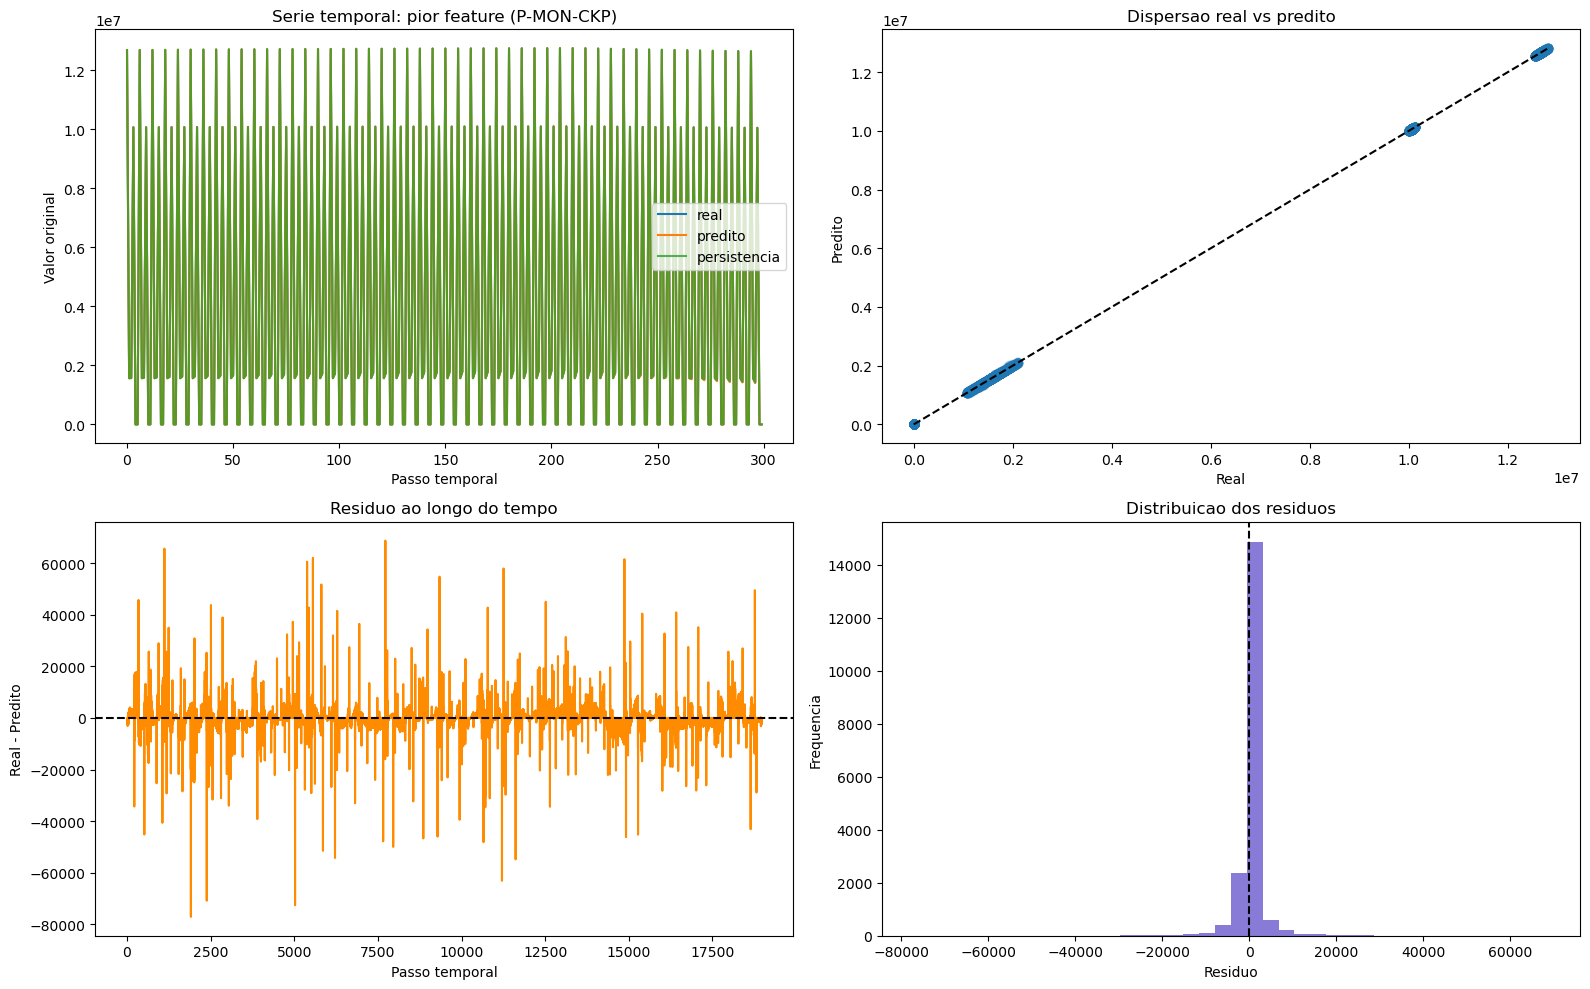

In [8]:
#inspeciona a feature mais dificil do teste
worst_feature = per_feature_original_df.iloc[0]["feature"]
local_df = predictions_df.copy()

real_local = inverse_transform_targets(local_df[[f"real__{worst_feature}"]].to_numpy(dtype=np.float32), bundle).reshape(-1)
pred_local = inverse_transform_targets(local_df[[f"pred__{worst_feature}"]].to_numpy(dtype=np.float32), bundle).reshape(-1)
persist_local = inverse_transform_targets(local_df[[f"persist__{worst_feature}"]].to_numpy(dtype=np.float32), bundle).reshape(-1)
residual_local = real_local - pred_local

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(real_local[:300], label="real")
axes[0, 0].plot(pred_local[:300], label="predito")
axes[0, 0].plot(persist_local[:300], label="persistencia", alpha=0.8)
axes[0, 0].set_title(f"Serie temporal: pior feature ({worst_feature})")
axes[0, 0].set_xlabel("Passo temporal")
axes[0, 0].set_ylabel("Valor original")
axes[0, 0].legend()

axes[0, 1].scatter(real_local, pred_local, alpha=0.25, label="modelo")
min_axis = min(real_local.min(), pred_local.min(), persist_local.min())
max_axis = max(real_local.max(), pred_local.max(), persist_local.max())
axes[0, 1].plot([min_axis, max_axis], [min_axis, max_axis], color="black", linestyle="--")
axes[0, 1].set_title("Dispersao real vs predito")
axes[0, 1].set_xlabel("Real")
axes[0, 1].set_ylabel("Predito")

axes[1, 0].plot(residual_local, color="darkorange")
axes[1, 0].axhline(0.0, color="black", linestyle="--")
axes[1, 0].set_title("Residuo ao longo do tempo")
axes[1, 0].set_xlabel("Passo temporal")
axes[1, 0].set_ylabel("Real - Predito")

axes[1, 1].hist(residual_local, bins=40, color="slateblue", alpha=0.8)
axes[1, 1].axvline(0.0, color="black", linestyle="--")
axes[1, 1].set_title("Distribuicao dos residuos")
axes[1, 1].set_xlabel("Residuo")
axes[1, 1].set_ylabel("Frequencia")

plt.tight_layout()
plt.show()


### Leitura dos graficos desta execucao

Os graficos mostram um comportamento interessante:

- `P-MON-CKP` apareceu como a feature mais dificil em erro absoluto, mas mesmo assim o modelo superou fortemente a persistencia nela
- em `P-MON-CKP`, o modelo acompanhou bem a forma oscilatoria da serie e manteve residuos relativamente centrados em zero, apesar de alguns picos
- `T-JUS-CKP` e `T-TPT` tambem melhoraram bastante em relacao ao baseline
- `P-ANULAR` e `P-TPT` continuaram sendo pontos mais sensiveis, com a persistencia ainda melhor em `MAE` para essas variaveis
- `P-JUS-CKGL` ficou praticamente constante nesse trecho de teste, por isso a persistencia teve erro zero e se tornou um baseline dificil de bater

A conclusao visual combina com as metricas: a `versao2` aprendeu melhor a dinamica das variaveis que realmente mudam, mas ainda nao domina completamente as variaveis muito estaveis ou com pequenas variacoes residuais.


## 5. Diagnostico final

O resultado final desta execucao foi positivo. A `versao2` superou a persistencia no teste de forma clara quando olhamos `MAE` e `RMSE` globais, especialmente por capturar muito melhor a dinamica de `P-MON-CKP`, `T-JUS-CKP` e `T-TPT`.

Ao mesmo tempo, o diagnostico por feature mostra que o problema ainda nao esta totalmente resolvido:

- a persistencia segue fortissima em variaveis quase constantes
- `P-ANULAR` ainda ficou pior que o baseline em erro absoluto
- `P-TPT` melhorou pouco
- `P-JUS-CKGL` estava tao estavel no teste que a persistencia virou praticamente o teto a ser batido


In [9]:
model_row = global_metrics_original_df.loc[global_metrics_original_df["modelo"] == "Modelo_v2"].iloc[0]
persist_row = global_metrics_original_df.loc[global_metrics_original_df["modelo"] == "Persistencia"].iloc[0]

global_rmse_gain_pct = (persist_row["RMSE"] - model_row["RMSE"]) / max(persist_row["RMSE"], 1e-8) * 100
global_mae_gain_pct = (persist_row["MAE"] - model_row["MAE"]) / max(persist_row["MAE"], 1e-8) * 100

if global_mae_gain_pct > 5:
    final_assessment = "a versao 2 superou a persistencia de forma consistente neste arquivo"
elif global_mae_gain_pct > 0:
    final_assessment = "a versao 2 melhorou ligeiramente a persistencia neste arquivo"
else:
    final_assessment = "a versao 2 ainda nao venceu a persistencia neste arquivo"

diagnosis_df = pd.DataFrame(
    {
        "aspecto": [
            "avaliacao_final",
            "ganho_global_rmse_vs_persistencia_pct",
            "ganho_global_mae_vs_persistencia_pct",
            "r2_medio_modelo_v2",
            "feature_mais_dificil",
            "feature_mais_facil",
        ],
        "valor": [
            final_assessment,
            float(global_rmse_gain_pct),
            float(global_mae_gain_pct),
            float(model_row["R2_medio"]),
            per_feature_original_df.iloc[0]["feature"],
            per_feature_original_df.iloc[-1]["feature"],
        ],
    }
)
diagnosis_df


,aspecto,valor
0,avaliacao_final,a versao 2 superou a persistencia de forma con...
1,ganho_global_rmse_vs_persistencia_pct,55.278205
2,ganho_global_mae_vs_persistencia_pct,65.013339
3,r2_medio_modelo_v2,0.832907
4,feature_mais_dificil,P-MON-CKP
5,feature_mais_facil,T-TPT


## 6. Fechamento

Nesta execucao, a `versao2` mostrou que a arquitetura hibrida residual foi um avanço real sobre a `versao1`. O ganho global no teste foi grande, e desta vez o modelo conseguiu superar a persistencia de forma clara no criterio mais relevante para previsao numerica: erro absoluto e erro quadratico medio.

O proximo passo natural nao e mais "trocar qualquer coisa aleatoriamente", e sim refinar onde o modelo ainda perde: variaveis muito estaveis, calibracao fina de `P-ANULAR` e pequenos ganhos residuais em `P-TPT`.
